# Análise de Vendas com Python

## Objetivo do Projeto

Este projeto realiza uma análise exploratória de dados (EDA) utilizando Python para entender padrões de vendas, identificar produtos mais vendidos e analisar a distribuição geográfica das vendas.

Ferramentas utilizadas:

- Python
- Pandas
- Matplotlib
- Seaborn
- Jupyter Notebook

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv('dados/sales_data_sample.csv', encoding='latin1')

df.head()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,...,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium


## Visualização inicial dos dados

Nesta etapa foi realizada uma inspeção inicial do dataset utilizando o método `head()` para visualizar as primeiras linhas da base de dados.

Essa análise inicial permite compreender a estrutura do dataset, identificar as colunas disponíveis e ter uma primeira visão sobre os tipos de informações presentes.

Entre os dados disponíveis estão:

- informações de pedidos
- valores de vendas
- linhas de produtos
- informações de clientes
- localização geográfica das vendas

Essa etapa é fundamental para orientar as análises exploratórias realizadas nas etapas seguintes.

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ORDERNUMBER       2823 non-null   int64  
 1   QUANTITYORDERED   2823 non-null   int64  
 2   PRICEEACH         2823 non-null   float64
 3   ORDERLINENUMBER   2823 non-null   int64  
 4   SALES             2823 non-null   float64
 5   ORDERDATE         2823 non-null   str    
 6   STATUS            2823 non-null   str    
 7   QTR_ID            2823 non-null   int64  
 8   MONTH_ID          2823 non-null   int64  
 9   YEAR_ID           2823 non-null   int64  
 10  PRODUCTLINE       2823 non-null   str    
 11  MSRP              2823 non-null   int64  
 12  PRODUCTCODE       2823 non-null   str    
 13  CUSTOMERNAME      2823 non-null   str    
 14  PHONE             2823 non-null   str    
 15  ADDRESSLINE1      2823 non-null   str    
 16  ADDRESSLINE2      302 non-null    str    
 17  CITY  

## Estrutura do dataset

A função `info()` foi utilizada para analisar a estrutura da base de dados.

Essa análise permite identificar:

- quantidade de registros
- tipos de dados de cada coluna
- presença de valores nulos

Compreender a estrutura dos dados é uma etapa importante do processo de análise, pois garante que as variáveis estão no formato adequado para as análises posteriores.

In [5]:
df.describe()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,QTR_ID,MONTH_ID,YEAR_ID,MSRP
count,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.00000,2823.000000
mean,10258.725115,35.092809,83.658544,6.466171,3553.889072,2.717676,7.092455,2003.81509,100.715551
std,92.085478,9.741443,20.174277,4.225841,1841.865106,1.203878,3.656633,0.69967,40.187912
min,10100.000000,6.000000,26.880000,1.000000,482.130000,1.000000,1.000000,2003.00000,33.000000
25%,10180.000000,27.000000,68.860000,3.000000,2203.430000,2.000000,4.000000,2003.00000,68.000000
50%,10262.000000,35.000000,95.700000,6.000000,3184.800000,3.000000,8.000000,2004.00000,99.000000
75%,10333.500000,43.000000,100.000000,9.000000,4508.000000,4.000000,11.000000,2004.00000,124.000000
max,10425.000000,97.000000,100.000000,18.000000,14082.800000,4.000000,12.000000,2005.00000,214.000000


## Estatísticas descritivas

Nesta etapa foram analisadas as estatísticas descritivas das variáveis numéricas do dataset.

O método `describe()` permite observar métricas importantes como:

- média
- desvio padrão
- valores mínimos e máximos
- quartis da distribuição

Essas informações ajudam a compreender melhor o comportamento dos dados e identificar possíveis outliers ou padrões iniciais nas vendas.

In [7]:
df.columns

Index(['ORDERNUMBER', 'QUANTITYORDERED', 'PRICEEACH', 'ORDERLINENUMBER',
       'SALES', 'ORDERDATE', 'STATUS', 'QTR_ID', 'MONTH_ID', 'YEAR_ID',
       'PRODUCTLINE', 'MSRP', 'PRODUCTCODE', 'CUSTOMERNAME', 'PHONE',
       'ADDRESSLINE1', 'ADDRESSLINE2', 'CITY', 'STATE', 'POSTALCODE',
       'COUNTRY', 'TERRITORY', 'CONTACTLASTNAME', 'CONTACTFIRSTNAME',
       'DEALSIZE'],
      dtype='str')

In [8]:
total_sales = df['SALES'].sum()

print("Faturamento total:", total_sales)

Faturamento total: 10032628.85


## Análise geral das vendas

Nesta etapa foi realizada uma análise agregada das vendas para compreender o volume total de receita gerado pelos pedidos registrados no dataset.

A análise das vendas totais é um ponto de partida importante para entender o desempenho geral do negócio e servir de base para análises mais específicas, como vendas por cliente, produto ou região.

In [12]:
sales_product = df.groupby('PRODUCTLINE')['SALES'].sum().sort_values(ascending=False)

sales_product

PRODUCTLINE
Classic Cars        3919615.66
Vintage Cars        1903150.84
Motorcycles         1166388.34
Trucks and Buses    1127789.84
Planes               975003.57
Ships                714437.13
Trains               226243.47
Name: SALES, dtype: float64

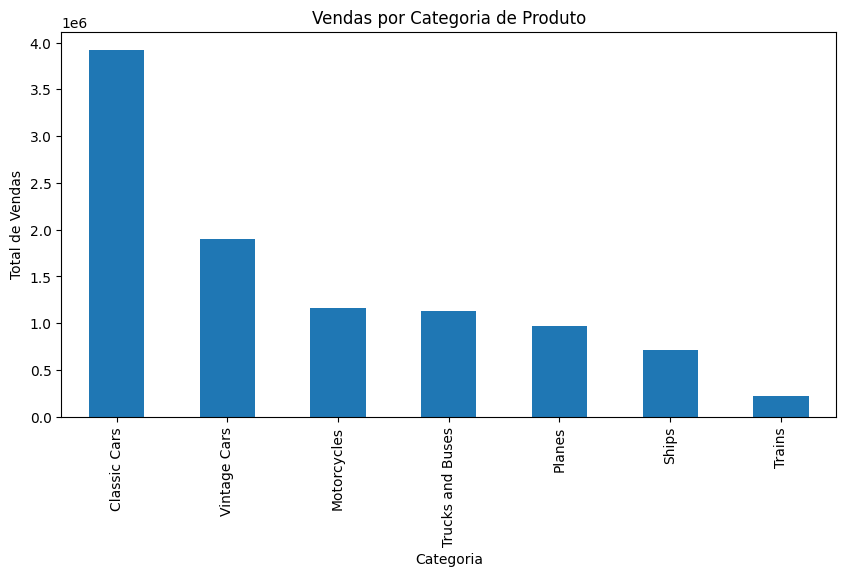

In [20]:
sales_product.plot(kind='bar', figsize=(10,5))

plt.title("Vendas por Categoria de Produto")
plt.xlabel("Categoria")
plt.ylabel("Total de Vendas")

plt.show()

## 📊 Visualização das vendas por categoria de produto

Após calcular o total de vendas por linha de produto, foi criada uma visualização em gráfico de barras para facilitar a interpretação dos dados.

O gráfico apresenta o volume total de vendas para cada categoria de produto presente no dataset. A utilização de uma visualização gráfica permite identificar rapidamente quais categorias possuem maior participação no faturamento da empresa.

Gráficos de barras são particularmente úteis nesse tipo de análise, pois permitem comparar facilmente diferentes categorias.

### Insight

A partir dessa visualização é possível identificar quais linhas de produtos possuem maior desempenho em vendas.

Essa informação pode ser utilizada para:

- direcionar campanhas de marketing para produtos de maior demanda
- melhorar o planejamento de estoque
- identificar oportunidades de crescimento em categorias com menor volume de vendas

Além disso, essa análise ajuda a empresa a compreender melhor o comportamento de consumo dos clientes.

In [13]:
sales_month = df.groupby('MONTH_ID')['SALES'].sum()

sales_month

MONTH_ID
1      785874.44
2      810441.90
3      754501.39
4      669390.96
5      923972.56
6      454756.78
7      514875.97
8      659310.57
9      584724.27
10    1121215.22
11    2118885.67
12     634679.12
Name: SALES, dtype: float64

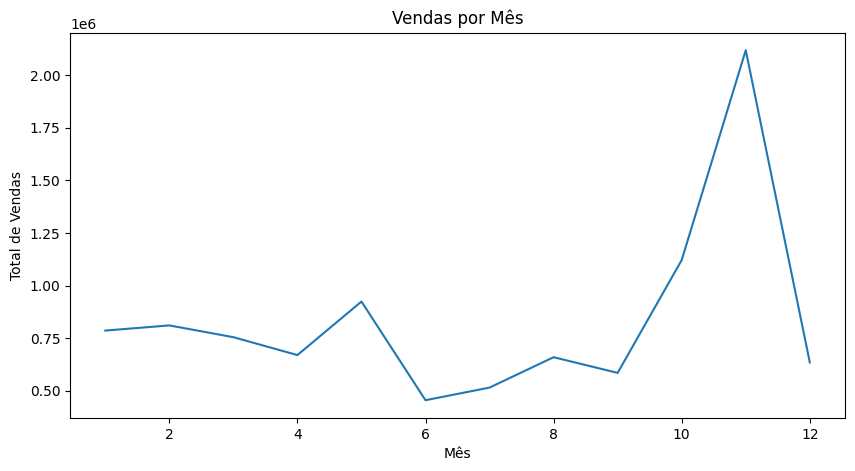

In [15]:
sales_month.plot(figsize=(10,5))

plt.title("Vendas por Mês")
plt.xlabel("Mês")
plt.ylabel("Total de Vendas")

plt.show()

## 📈 Análise de vendas por mês

Nesta etapa foi realizada uma análise temporal das vendas com o objetivo de identificar como o volume de vendas se comporta ao longo dos meses.

Para isso, os dados foram agregados por mês e o total de vendas foi calculado para cada período. Em seguida, foi criado um gráfico de linha para visualizar a evolução das vendas ao longo do tempo.

A visualização temporal permite identificar tendências, padrões de crescimento ou queda nas vendas e possíveis períodos de maior demanda.

### Insight

A análise mensal das vendas permite identificar padrões sazonais no comportamento de compra dos clientes.

Com base nessas informações, a empresa pode:

- planejar melhor o estoque para períodos de maior demanda
- criar campanhas promocionais em meses de menor volume de vendas
- antecipar estratégias comerciais para períodos de maior faturamento

Esse tipo de análise é importante para apoiar decisões estratégicas e melhorar o planejamento operacional do negócio.

In [14]:
sales_country = df.groupby('COUNTRY')['SALES'].sum().sort_values(ascending=False)

sales_country.head(10)

COUNTRY
USA          3627982.83
Spain        1215686.92
France       1110916.52
Australia     630623.10
UK            478880.46
Italy         374674.31
Finland       329581.91
Norway        307463.70
Singapore     288488.41
Denmark       245637.15
Name: SALES, dtype: float64

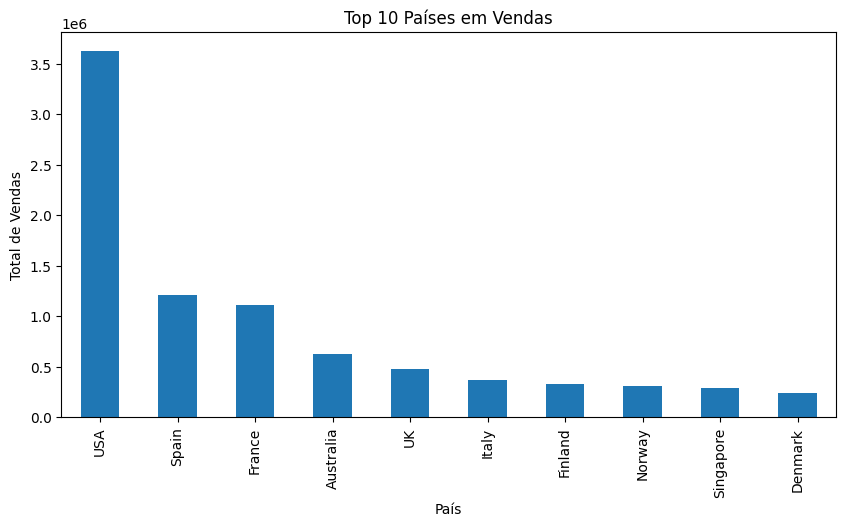

In [17]:
sales_country.head(10).plot(kind='bar', figsize=(10,5))

plt.title("Top 10 Países em Vendas")
plt.xlabel("País")
plt.ylabel("Total de Vendas")

plt.show()

## 🌎 Análise de vendas por país

Nesta etapa foi realizada uma análise das vendas agregadas por país com o objetivo de identificar quais mercados possuem maior participação no faturamento da empresa.

Os dados foram agrupados pela coluna **COUNTRY**, e em seguida foi calculado o total de vendas para cada país. Para facilitar a interpretação, foi criada uma visualização mostrando os **10 países com maior volume de vendas**.

Essa análise permite compreender a distribuição geográfica das vendas e identificar quais regiões possuem maior relevância para o negócio.

### Insight

A identificação dos países com maior volume de vendas permite que a empresa compreenda quais mercados são mais estratégicos.

Com base nessas informações, a empresa pode:

- direcionar campanhas de marketing para mercados com maior potencial
- fortalecer a presença comercial em regiões com maior demanda
- analisar oportunidades de expansão em novos mercados

Além disso, essa análise ajuda a entender melhor o comportamento de compra em diferentes regiões.

In [15]:
top_clientes = (
    df.groupby('CUSTOMERNAME')['SALES']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_clientes

CUSTOMERNAME
Euro Shopping Channel           912294.11
Mini Gifts Distributors Ltd.    654858.06
Australian Collectors, Co.      200995.41
Muscle Machine Inc              197736.94
La Rochelle Gifts               180124.90
Dragon Souveniers, Ltd.         172989.68
Land of Toys Inc.               164069.44
The Sharp Gifts Warehouse       160010.27
AV Stores, Co.                  157807.81
Anna's Decorations, Ltd         153996.13
Name: SALES, dtype: float64

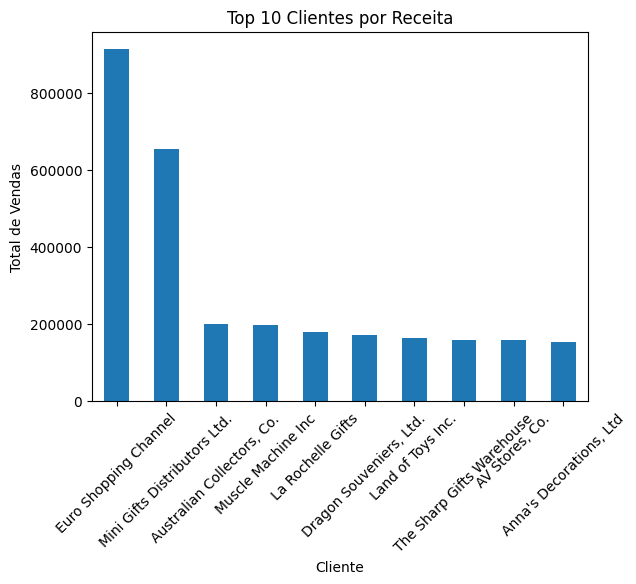

In [16]:
import matplotlib.pyplot as plt

top_clientes.plot(kind='bar')

plt.title('Top 10 Clientes por Receita')
plt.xlabel('Cliente')
plt.ylabel('Total de Vendas')
plt.xticks(rotation=45)

plt.show()

## Análise dos principais clientes

A análise dos dados mostra que um pequeno grupo de clientes concentra grande parte da receita total.

Esse padrão é comum em muitos negócios e pode indicar uma forte dependência de clientes estratégicos.

### Insight

A empresa pode desenvolver estratégias para:

- fortalecer o relacionamento com esses clientes
- oferecer programas de fidelidade
- identificar novos clientes com perfil semelhante

In [17]:
top_produtos = (
    df.groupby('PRODUCTLINE')['SALES']
    .sum()
    .sort_values(ascending=False)
)

top_produtos

PRODUCTLINE
Classic Cars        3919615.66
Vintage Cars        1903150.84
Motorcycles         1166388.34
Trucks and Buses    1127789.84
Planes               975003.57
Ships                714437.13
Trains               226243.47
Name: SALES, dtype: float64

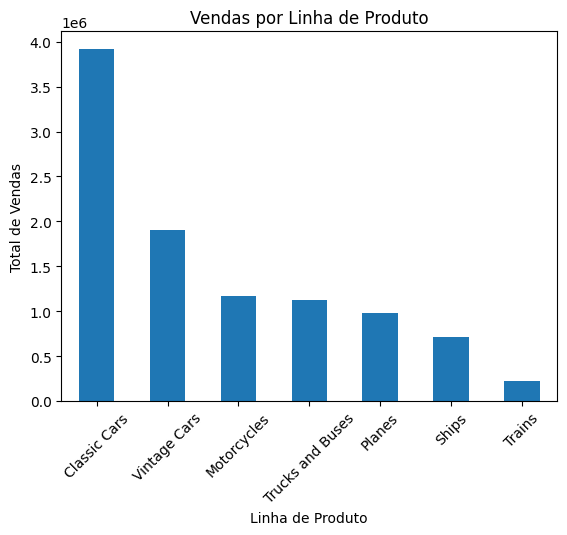

In [18]:
top_produtos.plot(kind='bar')

plt.title('Vendas por Linha de Produto')
plt.xlabel('Linha de Produto')
plt.ylabel('Total de Vendas')
plt.xticks(rotation=45)

plt.show()

## Análise das linhas de produto

A análise mostra quais categorias de produtos geram maior volume de vendas.

### Insight

Algumas linhas de produtos concentram grande parte da receita total da empresa.  
Isso indica que esses produtos são estratégicos para o negócio.

A empresa pode utilizar essa informação para:

- direcionar campanhas de marketing
- aumentar o estoque desses produtos
- identificar padrões de consumo dos clientes

# 📊 Insights da Análise de Vendas

## 1. Desempenho por categoria de produto
A análise das vendas por categoria mostra que algumas linhas de produtos concentram uma parcela significativa do faturamento total da empresa.

**Insight:**  
Esse comportamento sugere que determinadas categorias possuem maior demanda e representam produtos estratégicos para o negócio. A empresa pode utilizar essa informação para direcionar campanhas de marketing, otimizar a gestão de estoque e priorizar investimentos nessas categorias.

---

## 2. Sazonalidade das vendas
Ao analisar as vendas ao longo dos meses, é possível identificar variações no volume de faturamento em diferentes períodos do ano.

**Insight:**  
Essas variações podem indicar padrões sazonais de consumo, possivelmente associados a datas comemorativas ou períodos de maior demanda no mercado.

Com base nessas informações, a empresa pode:

- planejar melhor os níveis de estoque
- intensificar campanhas promocionais em períodos estratégicos
- antecipar ações comerciais para períodos de maior demanda

---

## 3. Distribuição geográfica das vendas
A análise das vendas por país permite identificar quais mercados possuem maior participação no faturamento da empresa.

**Insight:**  
Alguns países apresentam maior volume de vendas, indicando mercados com maior relevância estratégica para o negócio.

Essas informações podem apoiar decisões relacionadas a:

- expansão comercial
- investimentos em logística
- estratégias de marketing regional

---

## 4. Conclusão da análise
A análise exploratória permitiu identificar padrões importantes no comportamento das vendas.

Principais pontos observados:

- algumas categorias de produtos concentram grande parte do faturamento
- existem variações temporais que podem indicar padrões sazonais
- determinados mercados possuem maior relevância nas vendas globais

Esses insights podem auxiliar a empresa na definição de estratégias comerciais mais eficientes e na otimização da gestão de vendas.